# CBIS-DDSM clean dataset

This notebook shows how to read the clean CBIS-DDSM dataset, inspect labels, and display resized full mammograms.

Recommended main task: binary benign vs malignant classification using `is_malignant`.

Other possible tasks: multiclass `pathology`, `abnormality_type`, `assessment`, and subgroup analysis.


--------

# Dataset CBIS-DDSM

Este notebook muestra cómo leer el dataset limpio CBIS-DDSM, inspeccionar las etiquetas y visualizar mamografías completas redimensionadas.

Tarea principal recomendada: clasificación binaria benigno vs maligno usando `is_malignant`.

Otras tareas posibles: clasificación multiclase usando `pathology`, predicción del tipo de hallazgo usando `abnormality_type`, predicción de `assessment`, y análisis por subgrupos.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

# Reemplazar con tu ruta al dataset / Replace with your path to the dataset
#DATASET_DIR = Path("PATH-TO-DATASET/CBIS-DDSM-clean")
DATASET_DIR = Path(os.environ["SCRATCH"]) / "datasets" / "datatondatasets" / "CBIS-DDSM-clean"

ROOT = DATASET_DIR
print("DATASET_DIR =", DATASET_DIR)

def show_image(path, title=""):
    path = Path(path)
    if not path.exists():
        print("Missing image:", path)
        return
    image = Image.open(path)
    plt.figure(figsize=(4, 4))
    plt.imshow(image, cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.show()

ROOT


DATASET_DIR = /lustre/fsn1/projects/rech/dtn/uap38od/datasets/datatondatasets/CBIS-DDSM-clean


PosixPath('/lustre/fsn1/projects/rech/dtn/uap38od/datasets/datatondatasets/CBIS-DDSM-clean')

In [2]:
labels = pd.read_csv(ROOT / "labels.csv")
print(labels.shape)
labels.head()


(3568, 19)


,image,split,patient_id,left_or_right_breast,image_view,abnormality_id,abnormality_type,assessment,breast_density,pathology,is_malignant,subtlety,mass_shape,mass_margins,calc_type,calc_distribution,source_case_csv,source_image_file_path,source_series_instance_uid
0,train_mass_P_00001_LEFT_CC_1_1.png,train,P_00001,LEFT,CC,1,mass,4,3,MALIGNANT,1,4,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,NaN,NaN,mass_train.csv,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,1.3.6.1.4.1.9590.100.1.2.342386194811267636608...
1,train_mass_P_00001_LEFT_MLO_1_2.png,train,P_00001,LEFT,MLO,1,mass,4,3,MALIGNANT,1,4,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,NaN,NaN,mass_train.csv,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,1.3.6.1.4.1.9590.100.1.2.359308329312397897125...
2,train_mass_P_00004_LEFT_CC_1_3.png,train,P_00004,LEFT,CC,1,mass,4,3,BENIGN,0,3,ARCHITECTURAL_DISTORTION,ILL_DEFINED,NaN,NaN,mass_train.csv,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,1.3.6.1.4.1.9590.100.1.2.891800462110225318343...
3,train_mass_P_00004_LEFT_MLO_1_4.png,train,P_00004,LEFT,MLO,1,mass,4,3,BENIGN,0,3,ARCHITECTURAL_DISTORTION,ILL_DEFINED,NaN,NaN,mass_train.csv,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,1.3.6.1.4.1.9590.100.1.2.295360926313492745441...
4,train_mass_P_00004_RIGHT_MLO_1_5.png,train,P_00004,RIGHT,MLO,1,mass,4,3,BENIGN,0,5,OVAL,CIRCUMSCRIBED,NaN,NaN,mass_train.csv,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,1.3.6.1.4.1.9590.100.1.2.410524754913057908920...


In [3]:
print("Columns/Columnas:")
for column in labels.columns:
    print("-", column)


Columns/Columnas:
- image
- split
- patient_id
- left_or_right_breast
- image_view
- abnormality_id
- abnormality_type
- assessment
- breast_density
- pathology
- is_malignant
- subtlety
- mass_shape
- mass_margins
- calc_type
- calc_distribution
- source_case_csv
- source_image_file_path
- source_series_instance_uid


In [4]:
for column in ["split", "is_malignant", "pathology", "abnormality_type", "assessment", "breast_density", "image_view", "left_or_right_breast"]:
    if column in labels.columns:
        print("\n", column)
        display(labels[column].value_counts(dropna=False).to_frame("count"))



 split


,count
split,
train,2864
test,704



 is_malignant


,count
is_malignant,
0,2111
1,1457



 pathology


...

,count
breast_density,
2,1373
3,1103
4,554
1,536
0,2



 image_view


,count
image_view,
MLO,1896
CC,1672



 left_or_right_breast


,count
left_or_right_breast,
LEFT,1819
RIGHT,1749


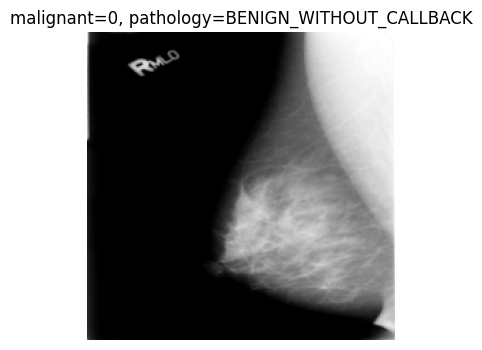

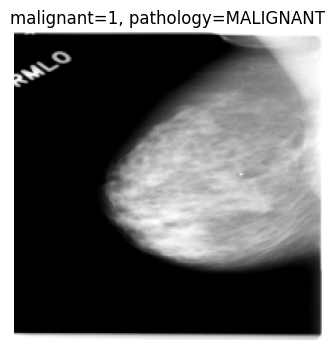

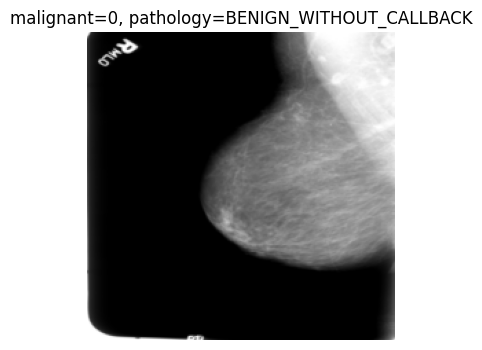

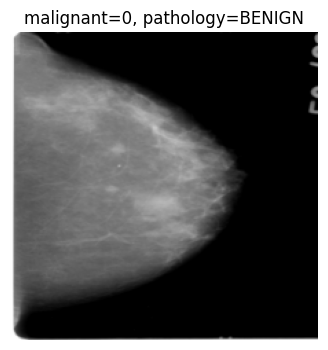

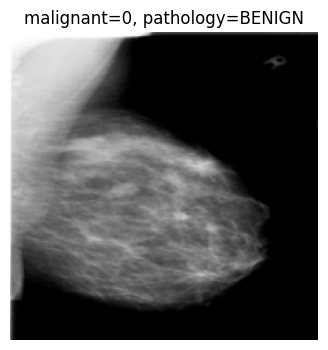

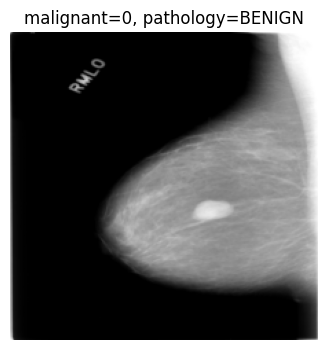

In [5]:
sample = labels.sample(min(6, len(labels)), random_state=1)
for _, row in sample.iterrows():
    title = f"malignant={row.get('is_malignant', '')}, pathology={row.get('pathology', '')}"
    show_image(ROOT / "images" / row["image"], title=title)
